In [1]:
import numpy as np
import json
import sys, os, importlib, math
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm
from skimage.segmentation import mark_boundaries
import io, imageio

from matplotlib import rc
rc('text',usetex=True)
rc('text.latex', preamble='\\usepackage{color}')

import shap_bpt as shap_bpt

In [2]:
import imageio as iio
from skimage.transform import resize
import hashlib

def load_rgb_image_from_file(filename, size=(224, 224, 3)):
    return cv2.imread(filename, cv2.IMREAD_COLOR)[:,:,::-1]

    
    image = iio.imread(filename)
    if len(image.shape)==2: # grayscale
        image = np.tile(image, reps=3)
    if image.shape[2]==4:
        image = image[:, :, 0:3]

#     print(hashlib.sha1( np.ascontiguousarray(image).view(np.uint8) ).hexdigest())

    # if image.shape != size:
    #     print(image)
    #     image = resize(image/255.0, size)*255
    #     print(image)
    return image.astype(np.uint8)

_ = load_rgb_image_from_file('../imgs/ImageNet-S/ILSVRC2012_val_00000089.JPEG')
_ = load_rgb_image_from_file('../imgs/ImageNet-S/ILSVRC2012_val_00000089.png')


In [3]:
image_fnames = [
    '../imgs/flamingo.png',
    '../imgs/egret.png',
    '../imgs/bird4.png',
    '../imgs/sorrel.png',
    '../imgs/00000001_000.png',
    '../imgs/lungaca20.jpeg',
    '../imgs/toucan.png',
]
# images = [ cv2.imread(f, cv2.IMREAD_COLOR)[:,:,::-1].astype(np.uint8) for f in image_fnames ]
images = [ load_rgb_image_from_file(f) for f in image_fnames ]

In [4]:
from skimage.segmentation import quickshift

In [5]:
%%time
print(images[0].shape)
shap_bpt.build_bpt_from_image(images[0])

(224, 224, 3)
CPU times: user 133 ms, sys: 7.27 ms, total: 140 ms
Wall time: 142 ms


In [6]:
%%time
quickshift(images[0])

CPU times: user 358 ms, sys: 6.06 ms, total: 364 ms
Wall time: 372 ms


array([[  1,   1,   1, ...,   4,   4,   4],
       [  1,   1,   1, ...,   4,   4,   4],
       [  1,   1,   1, ...,   4,   4,   4],
       ...,
       [124, 124, 124, ..., 128, 128, 128],
       [124, 124, 124, ..., 128, 128, 128],
       [124, 124, 124, ..., 128, 128, 128]])

In [7]:
%%time
bptrees = [ shap_bpt.build_bpt_from_image(image=img, use_8ways=True#, use_sqrt_area=False#squared_perimeter=False, squared_color=False#cv2.cvtColor(image_to_explain, cv2.COLOR_BGR2LAB), 
#                                           squared_perimeter=False, use_8ways=True, use_lab=True, squared_color=True
           ) for img in images ]

CPU times: user 8.02 s, sys: 200 ms, total: 8.22 s
Wall time: 8.67 s


In [8]:
# %%time
import matplotlib.colors as mcolors
cmap = [shap_bpt.hex_to_rgb(c[1]) for c in list(mcolors.XKCD_COLORS.items())]

def colorize(nodes, img, i):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    pxflat_image = img.reshape((img.shape[0] * img.shape[1], 3))
    colored = np.zeros_like(img, dtype=np.float32)
    flat_colored = colored.reshape(pxflat_image.shape)
    for node in nodes:
        if is_aa:
            clr = np.mean(np.mean(img[node.ymin:node.ymax, node.xmin:node.xmax, :], axis=1), axis=0)/255.0
            colored[ node.ymin:node.ymax, node.xmin:node.xmax ] = clr
        else:
            s,e = node.pixels_interval()
            clr = np.mean(pxflat_image[ node.bpt.pixels[s:e] ], axis=0)/255.0
            flat_colored[ node.bpt.pixels[s:e], :: ] = clr #np.array(cmap[s % len(cmap)])[0:3]
    return colored

def make_segments(nodes, img):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    flat_img = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint32)
    for i, node in enumerate(nodes):
        if is_aa:
            flat_img[ node.ymin:node.ymax, node.xmin:node.xmax ] = i
        else:
            s,e = node.pixels_interval()
            flat_img.ravel()[ node.bpt.pixels[s:e] ] = i
    return flat_img#.reshape((img.shape[0], img.shape[1]))

In [9]:
np.random.randint(0, 100)

17

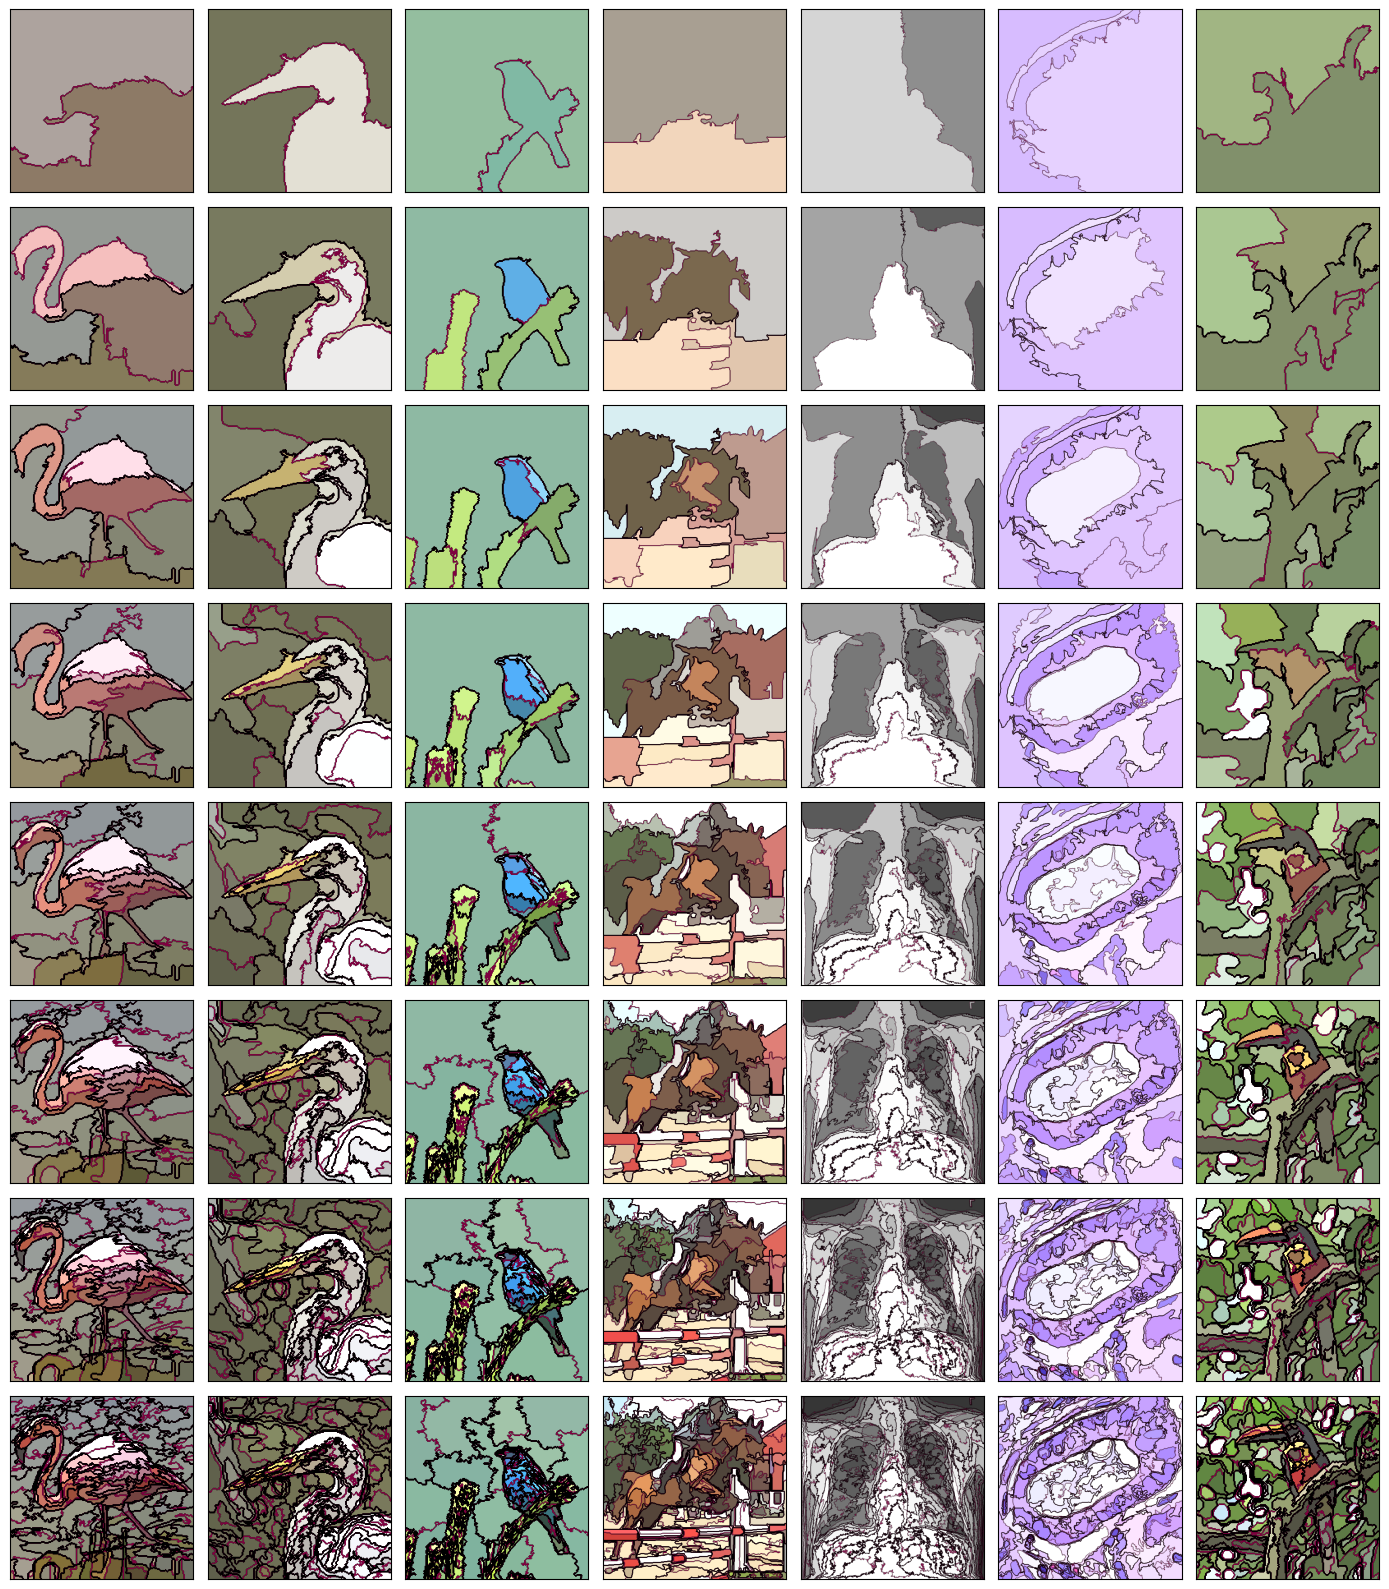

In [11]:
K=8
leaves = np.zeros(K, dtype=int)
fig, axes = plt.subplots(K, len(images), figsize=(2*len(images), 2*K))
for ii, image in enumerate(images):
    bptree = bptrees[ii]
    base_segment = shap_bpt.BaseSegment()
    # root_node = shap_bpt.AxisAlignedSegment(0, bptree.width, 0, bptree.height, base_segment)
    root_node = shap_bpt.BPT_Segment(bptree, bptree.N-1, base_segment)
    segments = [root_node]
    all_nodes = [root_node]
    prev_boundaries = None
    for jj in range(0,K):
        # index = np.random.randint(0, len(segments))
        # split = segments[index].split(None, None)
        # del segments[index]
        # segments += split
        new_segments = []
        for s in segments:
            split = s.split(s, s)
            if split is None:
                new_segments.append(s)
                leaves[ii] += 1
            else:
                new_segments.extend(split)
                all_nodes.extend(split)

        segments = new_segments

        ax = axes[jj,ii]
        img = colorize(segments, image, 0)
        img = np.clip(0.2 + img * 1.1, 0, 1)
        sgm = make_segments(segments, image)
        cut_color = (.5, 0, .25, 1)
        boundaries = mark_boundaries(np.tile((255,255,255,0), (image.shape[0],image.shape[1],1)), sgm, 
                                     mode='thick', color=cut_color)
        ax.set_xticks([]) ; ax.set_yticks([])
        ax.imshow(img)#, alpha=0.75)
        ax.imshow(boundaries)
        nshape = (image.shape[0]*image.shape[1], 4)
        boundaries.reshape(nshape)[ np.where(boundaries.reshape(nshape) == cut_color)[0] ] = (0,0,0,1)
        if prev_boundaries is not None:
            ax.imshow(prev_boundaries)

        prev_boundaries = boundaries

plt.tight_layout()
# plt.savefig('aa_expansion.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()